# Raman LTA Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120})
COLORS = {'40%': '#2196F3', '50%': '#4CAF50', '60%': '#FF9800', '70%': '#F44336'}
POWERS = ['40%', '50%', '60%', '70%']
print('Libraries loaded')

Libraries loaded


In [2]:
FILE_PATHS = {
    '40%': r'C:\Users\sukes\Downloads\new plotting same place\sec-10_power-40_i-10.xlsx',
    '50%': r'C:\Users\sukes\Downloads\new plotting same place\sec-10_power-50_i-10.xlsx',
    '60%': r'C:\Users\sukes\Downloads\new plotting same place\sec-10_power-60_i-10.xlsx',
    '70%': r'C:\Users\sukes\Downloads\new plotting same place\sec-10_power-70_i-10.xlsx',
}

def load_raman_excel(filepath, sheet=0):
    df_raw = pd.read_excel(filepath, sheet_name=sheet, header=None)
    data_start = None
    for i in range(min(10, len(df_raw))):
        try:
            float(df_raw.iloc[i, 2])
            data_start = i
            break
        except: pass
    if data_start is None: raise ValueError('No data')
    df = df_raw.iloc[data_start:].reset_index(drop=True)
    raman_shift = pd.to_numeric(df.iloc[:, 2], errors='coerce')
    dark_sub = pd.to_numeric(df.iloc[:, 3], errors='coerce')
    combined = pd.DataFrame({'shift': raman_shift, 'dark': dark_sub}).dropna()
    return combined['shift'].values, combined['dark'].values

datasets = {}
for power in POWERS:
    try:
        x, y = load_raman_excel(FILE_PATHS[power])
        datasets[power] = (x, y)
        print(f'{power}: {len(x)} pts | {x.min():.0f}-{x.max():.0f} cm^-1 | Max: {y.max():.0f}')
    except Exception as e:
        print(f'{power}: ERROR {e}')
print(f'Loaded {len(datasets)} files')

40%: 2048 pts | -46-2842 cm^-1 | Max: 4613
50%: 2048 pts | -46-2842 cm^-1 | Max: 6867
60%: 2048 pts | -46-2842 cm^-1 | Max: 7414
70%: 2048 pts | -46-2842 cm^-1 | Max: 8656
Loaded 4 files


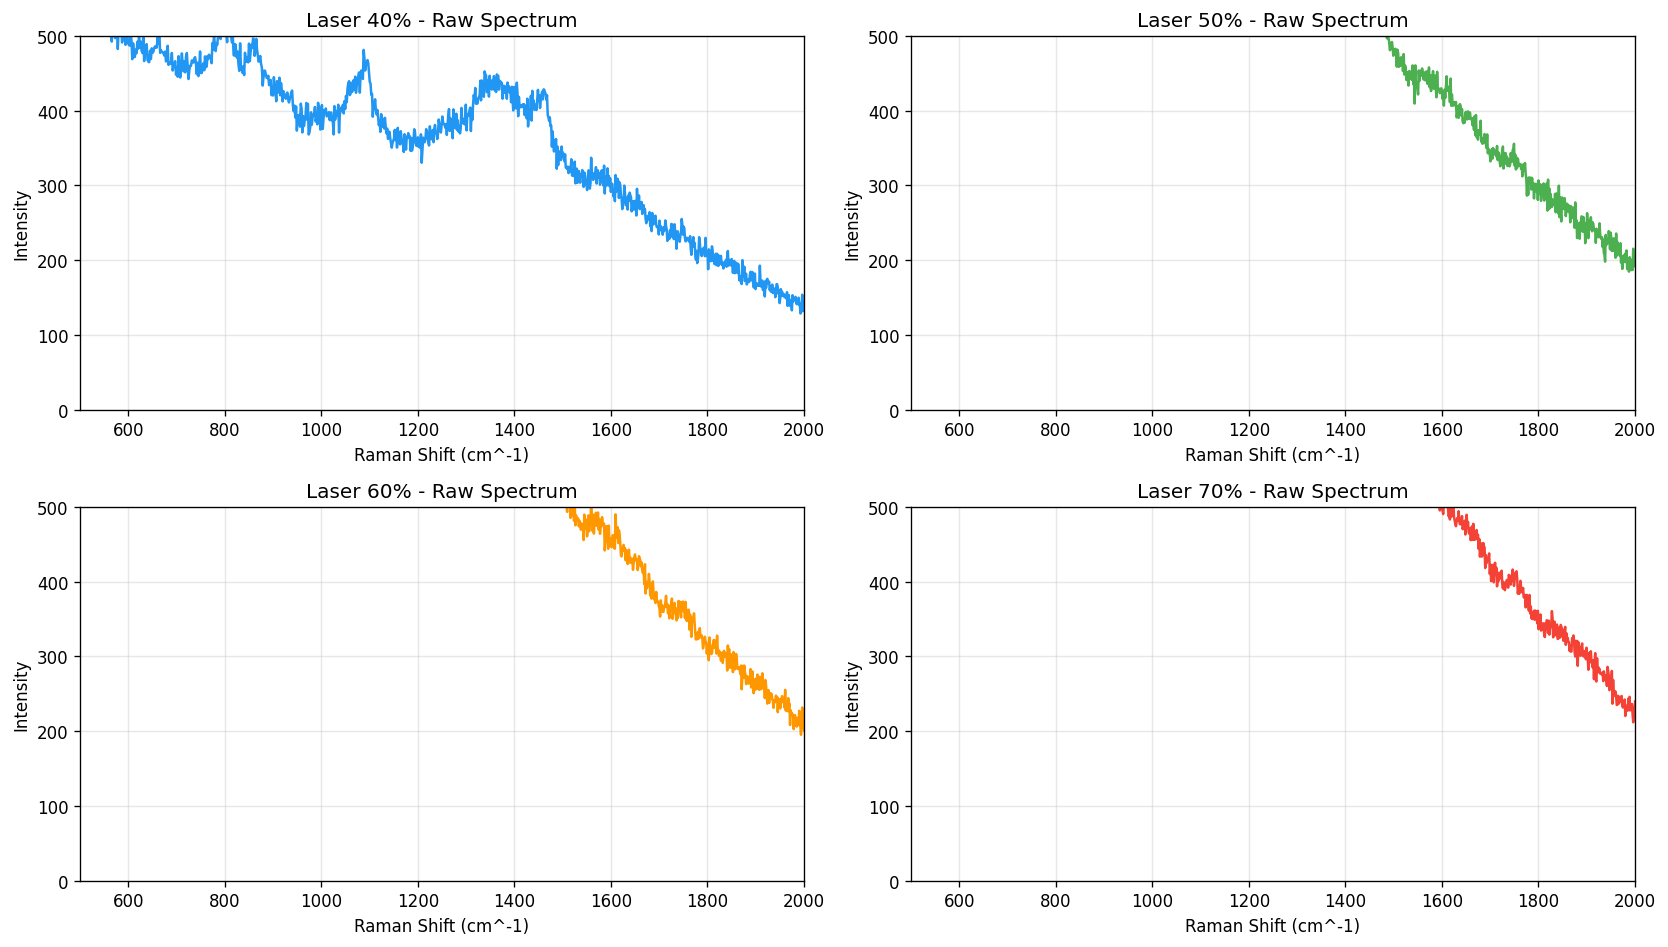

In [3]:
# Individual raw spectra plots for each laser power
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, power in enumerate(POWERS):
    if power not in datasets:
        axes[i].set_visible(False)
        continue
    x, y = datasets[power]
    axes[i].plot(x, y, color=COLORS[power])
    axes[i].set_title(f'Laser {power} - Raw Spectrum')
    axes[i].set_xlabel('Raman Shift (cm^-1)')
    axes[i].set_ylabel('Intensity (a.u.)')
    axes[i].set_xlim(500, 2000)
    axes[i].set_ylim(0, 100)
    axes[i].set_ylim(0, 500)
    axes[i].grid(False, alpha=0.3)
plt.tight_layout()
plt.show()

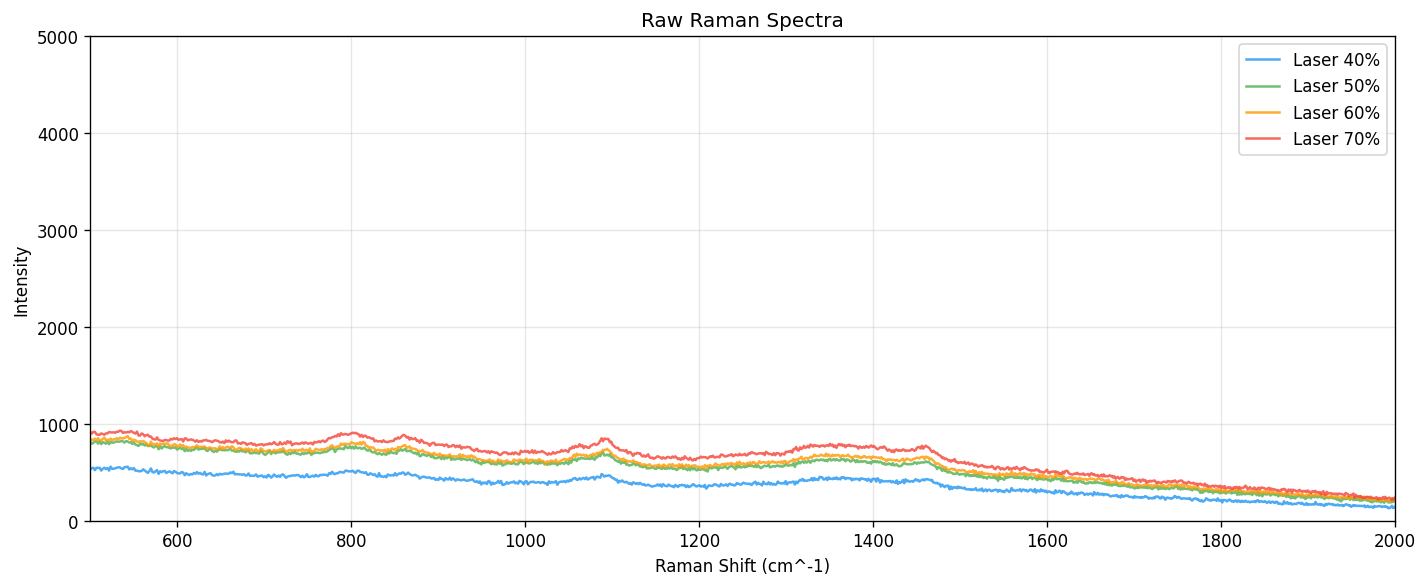

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
for power in POWERS:
    if power in datasets:
        x, y = datasets[power]
        ax.plot(x, y, color=COLORS[power], label=f'Laser {power}', alpha=0.8)
ax.set_xlabel('Raman Shift (cm^-1)')
ax.set_ylabel('Intensity (a.u.)')
ax.set_title('Raw Raman Spectra')
ax.legend()
ax.set_xlim(500, 2000)
ax.set_ylim(0, 5000)
ax.grid(False, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
def als_baseline(y, lam=1e5, p=0.01, niter=10):
    L = len(y)
    D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
    H = lam * D.T.dot(D)
    w = np.ones(L)
    for _ in range(niter):
        W = sparse.diags(w)
        z = spsolve(W + H, w * y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

datasets_corr = {}
for power in POWERS:
    if power in datasets:
        x, y = datasets[power]
        baseline = als_baseline(y)
        y_corr = y - baseline
        datasets_corr[power] = (x, y_corr)
        print(f'{power}: max corrected = {y_corr.max():.0f}')

40%: max corrected = 4620
50%: max corrected = 6881
60%: max corrected = 7420
70%: max corrected = 8666


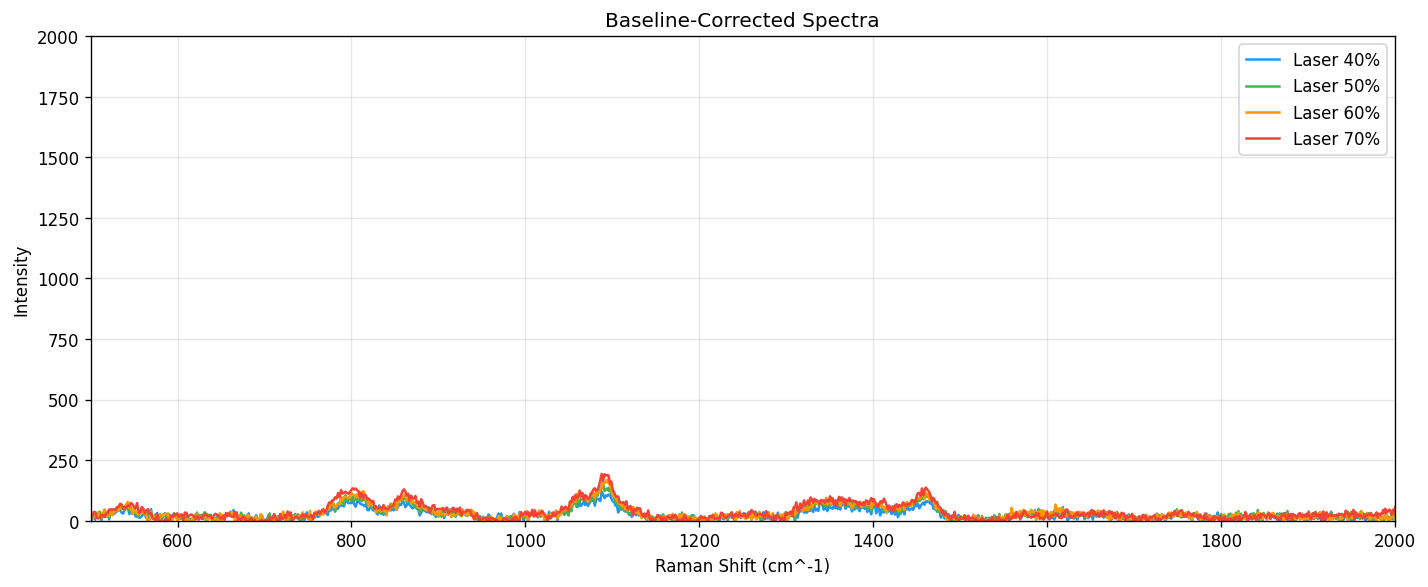

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
for power in POWERS:
    if power in datasets_corr:
        x, y = datasets_corr[power]
        ax.plot(x, y, color=COLORS[power], label=f'Laser {power}')
ax.set_xlabel('Raman Shift (cm^-1)')
ax.set_ylabel('Intensity (a.u.)')
ax.set_title('Baseline-Corrected Spectra')
ax.set_xlim(500, 2000)
ax.set_ylim(0, 2000)
ax.legend()
ax.grid(False, alpha=0.3)
plt.tight_layout()
plt.show()

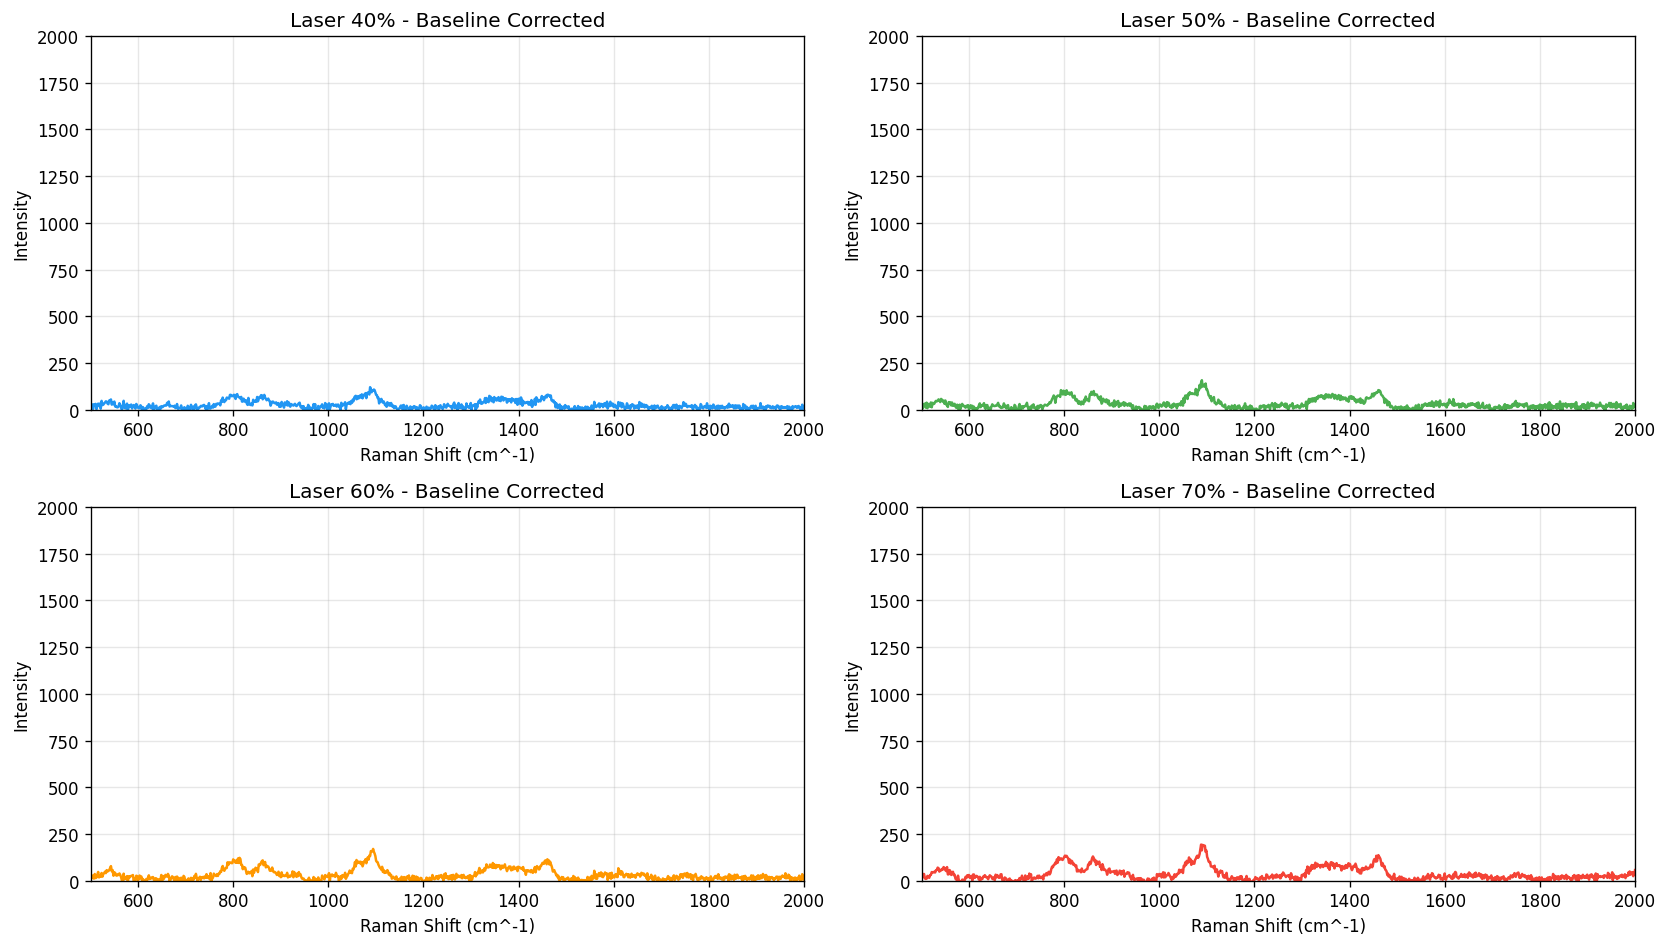

In [7]:
# Individual plots for each laser power
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, power in enumerate(POWERS):
    if power not in datasets_corr:
        axes[i].set_visible(False)
        continue
    x, y = datasets_corr[power]
    axes[i].plot(x, y, color=COLORS[power])
    axes[i].set_title(f'Laser {power} - Baseline Corrected')
    axes[i].set_xlabel('Raman Shift (cm^-1)')
    axes[i].set_ylabel('Intensity (a.u.)')
    axes[i].set_xlim(500, 2000)
    axes[i].set_ylim(0, 100)
    axes[i].set_ylim(0, 100)
    axes[i].set_ylim(0, 2000)
    axes[i].grid(False, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Better peak detection - focus on fingerprint region (200-1800 cm-1)
LTA_REGIONS = {'~1080': (1050, 1110), '~1230': (1200, 1260), '~1450': (1420, 1480)}
peaks = {}

for power in POWERS:
    if power not in datasets_corr: continue
    x, y = datasets_corr[power]
    
    # Filter: positive intensity + fingerprint region
    valid = (y > 0) & (x > 200) & (x < 1800)
    x_valid = x[valid]
    y_valid = y[valid]
    
    if len(x_valid) < 10:
        print(f'{power}: Not enough data')
        continue
    
    # Lower threshold, add prominence
    min_h = max(0.05 * y_valid.max(), 50)
    idx, props = find_peaks(y_valid, height=min_h, distance=20, prominence=min_h/3)
    peaks[power] = (x_valid[idx], y_valid[idx])
    
    print(f'{power}: {len(idx)} peaks in 200-1800 cm^-1')
    for px, py in sorted(zip(x_valid[idx], y_valid[idx]), key=lambda t: -t[1])[:10]:
        print(f'  {px:.0f}: {py:.0f}')

40%: 9 peaks in 200-1800 cm^-1
  203: 126
  1088: 120
  808: 83
  1462: 80
  865: 79
  1338: 74
  1405: 65
  248: 63
  543: 55
50%: 13 peaks in 200-1800 cm^-1
  203: 175
  1089: 158
  1460: 105
  793: 105
  862: 100
  248: 86
  1364: 84
  1058: 76
  1402: 72
  541: 58
60%: 12 peaks in 200-1800 cm^-1
  1094: 170
  203: 164
  813: 122
  1460: 115
  1059: 111
  862: 109
  1346: 95
  778: 79
  543: 78
  1380: 76
70%: 10 peaks in 200-1800 cm^-1
  1088: 193
  203: 182
  1460: 137
  802: 134
  860: 129
  1350: 101
  1398: 93
  1320: 84
  546: 73
  895: 65


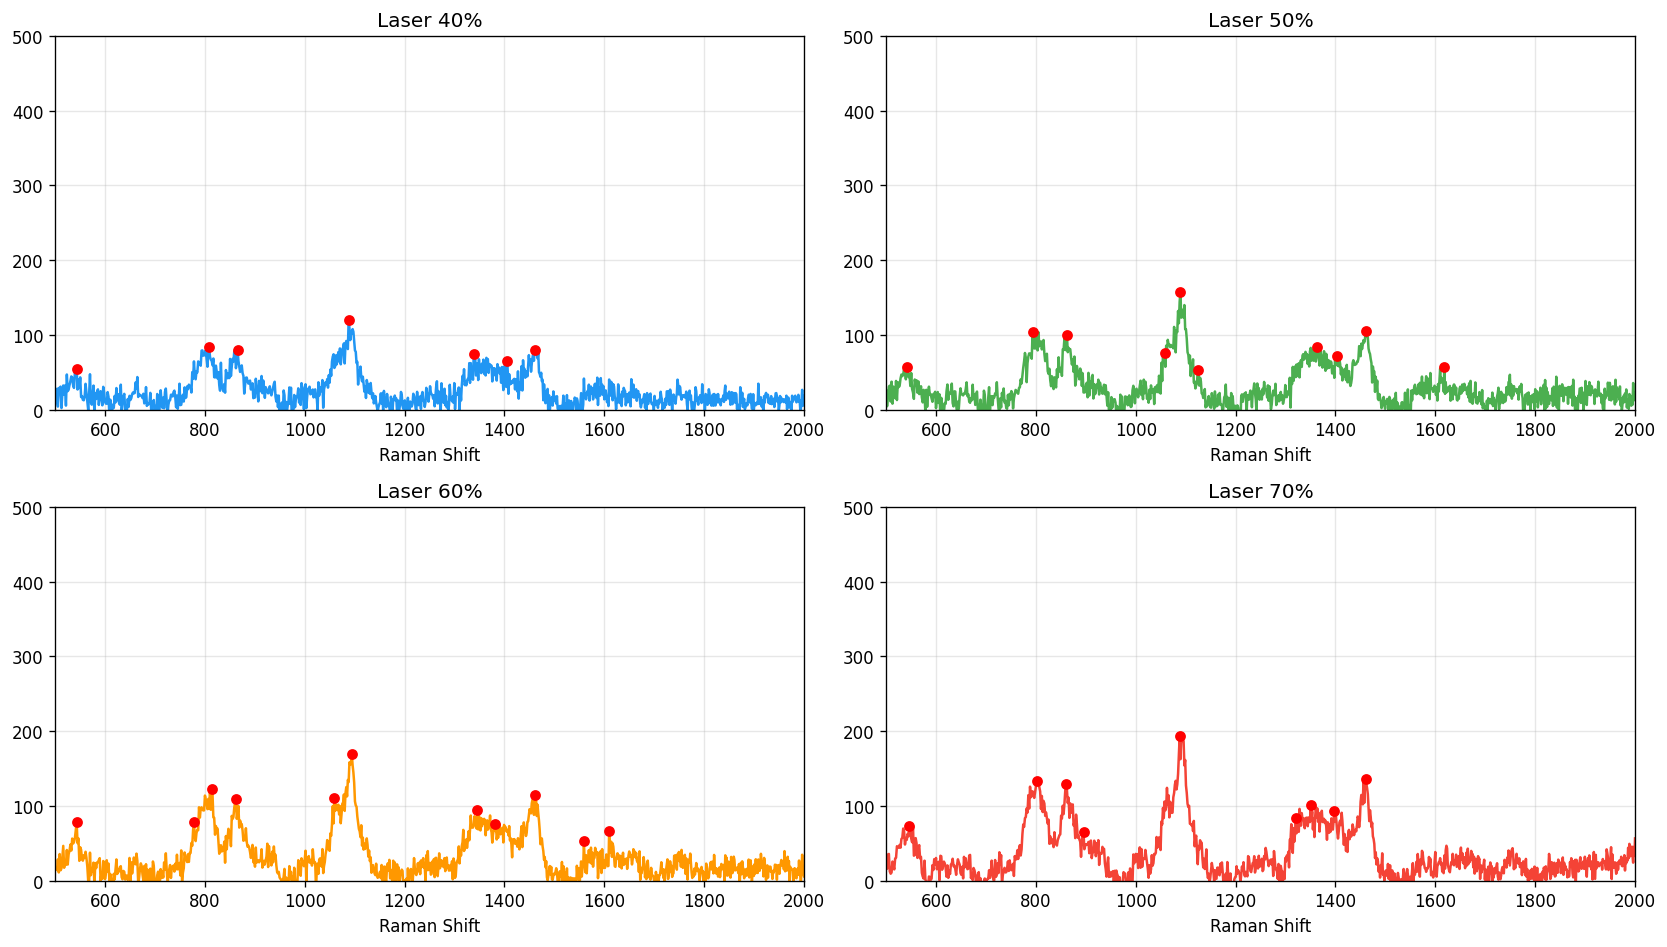

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, power in enumerate(POWERS):
    if power not in datasets_corr:
        axes[i].set_visible(False)
        continue
    x, y = datasets_corr[power]
    axes[i].plot(x, y, color=COLORS[power])
    if power in peaks:
        pkx, pky = peaks[power]
        axes[i].scatter(pkx, pky, color='red', s=30, zorder=5)
    axes[i].set_title(f'Laser {power}')
    axes[i].set_xlabel('Raman Shift')
    axes[i].grid(False, alpha=0.3)
    axes[i].set_xlim(500, 2000)
    axes[i].set_ylim(0, 100)
    axes[i].set_ylim(0, 500)
plt.tight_layout()
plt.show()